# Volume distribution & market profile — `qufin.volume_distribution`

Most indicators ask *how much* volume traded. This toolkit asks the more useful
question: **where** did it trade — across price and across time. That spatial
view of liquidity underpins auction-market theory and modern order-flow trading.

| Tool | What it measures | Key levels |
|---|---|---|
| **Volume profile** | volume traded at each price | POC, value area, HVN/LVN |
| **VWAP + bands** | the volume-weighted fair price | mean-reversion envelope |
| **Market Profile (TPO)** | *time* spent at each price | POC, initial balance, single prints |
| **CVD / delta** | aggressor buy vs sell imbalance | absorption, divergence |
| **Shape stats** | how concentrated the auction is | balance vs trend day |

The recurring idea: prices revisit **high-volume nodes** (fair value, magnets)
and slice quickly through **low-volume nodes** (rejected prices). The **POC**
(Point of Control — the most-traded price) and the **value area** (the central
~70% of volume) are the reference levels traders fade or break.

**Roadmap**

0. Data — synthetic intraday sessions with known structure
1. Volume profile — POC, value area, high/low-volume nodes
2. VWAP with standard-deviation bands
3. Market Profile / TPO — time at price
4. Order flow — CVD, delta footprint, and divergence
5. Profile shape — balance day vs trend day


In [1]:
from __future__ import annotations

import datetime as dt
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from qufin.data import OHLCV
from qufin.volume_distribution import (
    volume_profile, value_area, volume_profile_from_ticks,
    vwap_bands, session_vwap, anchored_vwap,
    tpo_profile,
    signed_tick_volume, cumulative_volume_delta, bar_delta, delta_divergence, delta_profile,
    classify_profile_shape, volume_concentration, volume_entropy,
)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


## 0. Data — synthetic intraday sessions

We build two contrasting 6.5-hour sessions of 5-minute bars with *known*
microstructure, so each tool's output is interpretable:

* a **balance day** — price rotates around a central value; volume piles up at
  one price (a tall, bell-shaped profile);
* a **trend day** — price grinds higher all session; volume is spread thinly
  across a wide range.

(Real intraday OHLCV from any vendor — IBKR, Revolut X — plugs straight into the
same `OHLCV` container.)


In [2]:
def make_session(kind, n=78, base_price=100.0, seed=0):
    rng = np.random.default_rng(seed)
    start = dt.datetime(2024, 3, 4, 14, 30, tzinfo=ZoneInfo('UTC'))   # ~09:30 ET
    ts = [start + dt.timedelta(minutes=5 * i) for i in range(n)]
    t = np.arange(n)
    u_shape = 1.0 + 1.4 * (np.cos(np.pi * (2 * t / (n - 1) - 1)) ** 2)  # heavy open/close
    if kind == 'balance':
        # Mean-reverting around base_price -> volume concentrates at the centre.
        close = np.empty(n); close[0] = base_price
        for i in range(1, n):
            close[i] = close[i-1] + 0.25 * (base_price - close[i-1]) + rng.normal(0, 0.18)
    else:  # trend up
        close = base_price + np.cumsum(np.abs(rng.normal(0.09, 0.05, n)))
    open_ = np.empty(n); open_[0] = base_price; open_[1:] = close[:-1]
    wick = np.abs(rng.normal(0.05, 0.03, n))
    high = np.maximum(open_, close) + wick
    low = np.minimum(open_, close) - wick
    vol = (800.0 * u_shape * (1.0 + 0.3 * rng.standard_normal(n))).clip(50)
    df = pl.DataFrame({'timestamp': ts, 'open': open_, 'high': high,
                       'low': low, 'close': close, 'volume': vol})
    return OHLCV.from_records(df)

bal = make_session('balance', seed=1)
trend = make_session('trend', seed=2)
print(f'balance day: {bal.n_bars} bars  close {bal.close()[0]:.2f} -> {bal.close()[-1]:.2f}')
print(f'trend day  : {trend.n_bars} bars  close {trend.close()[0]:.2f} -> {trend.close()[-1]:.2f}')


balance day: 78 bars  close 100.00 -> 100.10
trend day  : 78 bars  close 100.10 -> 107.29


## 1. Volume profile — POC, value area, HVN/LVN

`volume_profile` distributes each bar's volume across its high–low range and
bins it by price. It returns the **POC** (most-traded price — the magnet), the
**value area** (`VAL`–`VAH`, the central 70% of volume), and the indices of
**High/Low Volume Nodes** (local peaks/troughs in the histogram). HVNs are
acceptance (support/resistance); LVNs are rejection (fast-move zones).


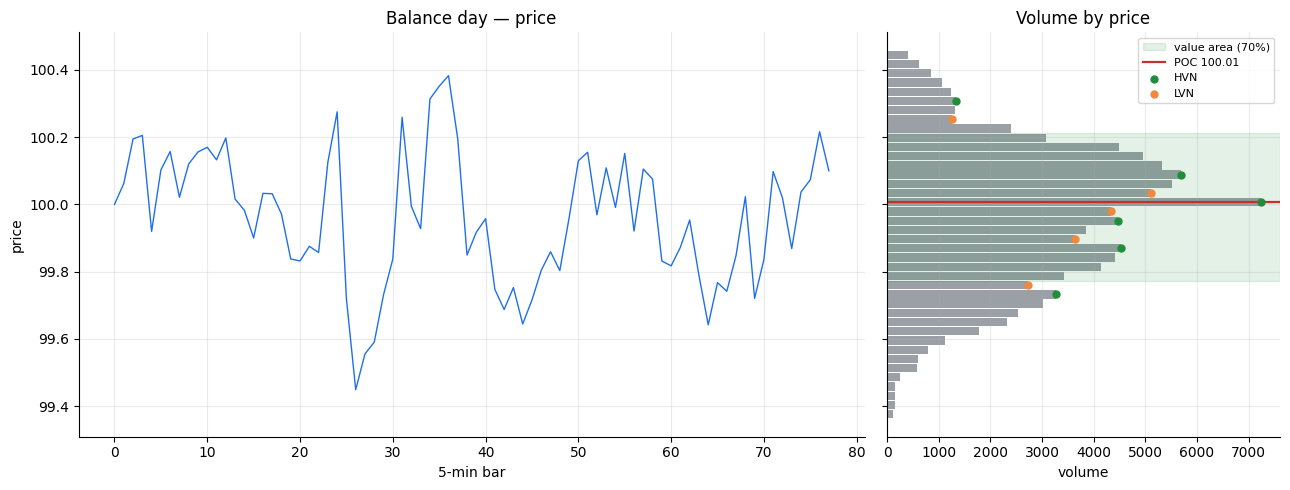

POC=100.01  value area=[99.77, 100.21]  #HVN=6  #LVN=5
narrower 50% value area = (99.8830670485363, 100.18453594226152)


In [3]:
prof = volume_profile(bal, n_bins=40)
centres = prof.bin_centres
fig, (axp, axv) = plt.subplots(1, 2, figsize=(13, 5), sharey=True, gridspec_kw={'width_ratios':[2,1]})
axp.plot(bal.close(), color='#1f6feb', lw=1.0)
axp.set_title('Balance day — price'); axp.set_xlabel('5-min bar'); axp.set_ylabel('price')
axv.barh(centres, prof.volume, height=(centres[1]-centres[0]) * 0.9, color='#9aa0a6')
axv.axhspan(prof.val, prof.vah, color='#1f8e3a', alpha=0.12, label='value area (70%)')
axv.axhline(prof.poc, color='#c4302b', lw=1.6, label=f'POC {prof.poc:.2f}')
axv.scatter(prof.volume[prof.hvn_idx], centres[prof.hvn_idx], color='#1f8e3a', s=25, zorder=3, label='HVN')
axv.scatter(prof.volume[prof.lvn_idx], centres[prof.lvn_idx], color='#f0883e', s=25, zorder=3, label='LVN')
axv.set_title('Volume by price'); axv.set_xlabel('volume'); axv.legend(fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()
print(f'POC={prof.poc:.2f}  value area=[{prof.val:.2f}, {prof.vah:.2f}]  '
      f'#HVN={len(prof.hvn_idx)}  #LVN={len(prof.lvn_idx)}')
print(f'narrower 50% value area = {value_area(prof, 0.50)}')


## 2. VWAP with standard-deviation bands

**VWAP** is the volume-weighted average price — the execution benchmark
institutions are measured against, and a powerful intraday mean. `vwap_bands`
adds **volume-weighted σ envelopes**: on a balance day price oscillates between
the ±1σ/±2σ bands and reverts to VWAP, exactly the behaviour mean-reversion
intraday traders fade.


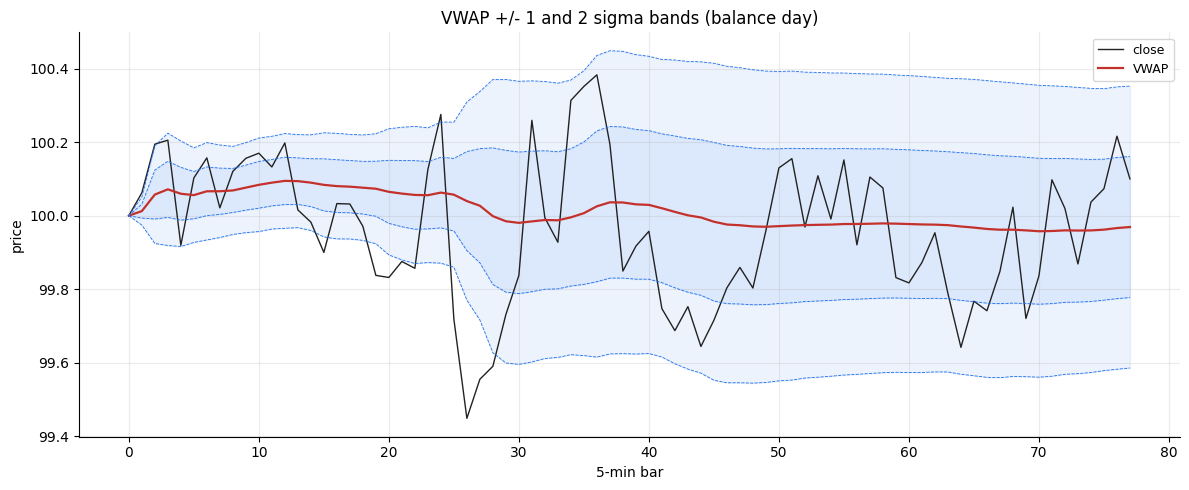

final VWAP = 99.97   fraction of closes within the +/-2 sigma band = 85%


In [4]:
vb = vwap_bands(bal.high(), bal.low(), bal.close(), bal.volume(), std_mults=(1.0, 2.0))
x = np.arange(bal.n_bars)
fig, ax = plt.subplots()
ax.plot(x, bal.close(), color='#222', lw=1.0, label='close')
ax.plot(x, vb.vwap, color='#c4302b', lw=1.6, label='VWAP')
for j, m in enumerate(vb.std_mults):
    ax.fill_between(x, vb.lower[:, j], vb.upper[:, j], color='#1f6feb', alpha=0.08)
    ax.plot(x, vb.upper[:, j], color='#1f6feb', lw=0.6, ls='--')
    ax.plot(x, vb.lower[:, j], color='#1f6feb', lw=0.6, ls='--')
ax.set_title('VWAP +/- 1 and 2 sigma bands (balance day)')
ax.set_xlabel('5-min bar'); ax.set_ylabel('price'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

inside = np.mean(np.abs(bal.close() - vb.vwap) <= 2 * (vb.upper[:, 1] - vb.vwap) / 2)
print(f'final VWAP = {vb.vwap[-1]:.2f}   fraction of closes within the +/-2 sigma band = {inside:.0%}')


## 3. Market Profile / TPO — time at price

Where the volume profile weights by *volume*, the **Market Profile** weights by
*time*: each 30-minute bracket gets a letter (A, B, …) and every price it trades
earns one TPO. The result reveals the **initial balance** (first hour's range),
**single prints** (prices touched by just one bracket — thin, often-revisited
levels), and **range extension** beyond the opening balance — the classic
auction read of a session.


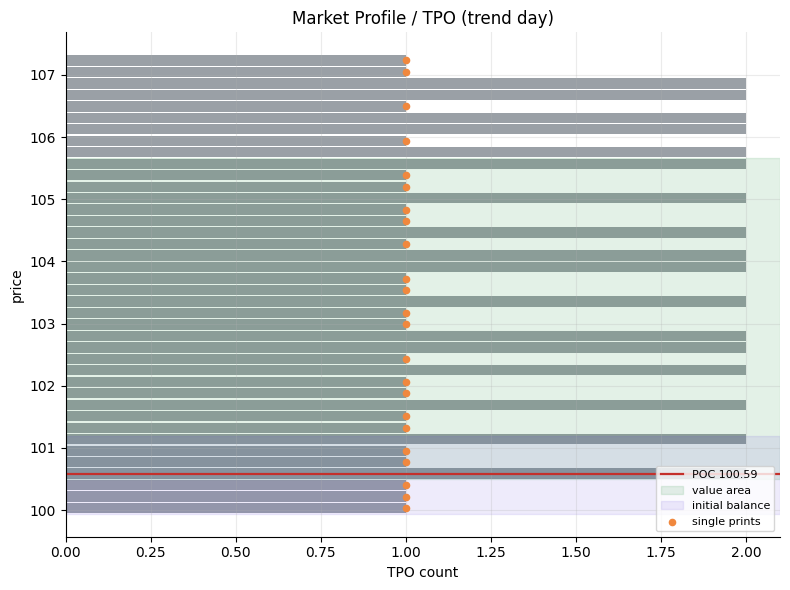

POC=100.59  IB=[99.94, 101.20]  range-ext up=True down=False  #single prints=23
first few bins:  100.0:A  100.2:A  100.4:A  100.6:AB  100.8:B


In [5]:
tpo = tpo_profile(trend, n_bins=40, period='30m', n_initial=2)
centres = tpo.bin_centres
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(centres, tpo.tpo_counts, height=(centres[1]-centres[0]) * 0.9, color='#9aa0a6')
ax.axhline(tpo.poc, color='#c4302b', lw=1.6, label=f'POC {tpo.poc:.2f}')
ax.axhspan(tpo.val, tpo.vah, color='#1f8e3a', alpha=0.12, label='value area')
ib_lo, ib_hi = tpo.initial_balance
ax.axhspan(ib_lo, ib_hi, color='#5b3fd8', alpha=0.10, label='initial balance')
if tpo.single_prints.size:
    ax.scatter(np.ones(tpo.single_prints.size), centres[tpo.single_prints],
               color='#f0883e', s=20, zorder=3, label='single prints')
ax.set_title('Market Profile / TPO (trend day)'); ax.set_xlabel('TPO count'); ax.set_ylabel('price')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()
print(f'POC={tpo.poc:.2f}  IB=[{ib_lo:.2f}, {ib_hi:.2f}]  '
      f'range-ext up={tpo.range_extension_up} down={tpo.range_extension_down}  '
      f'#single prints={tpo.single_prints.size}')
print('first few bins:  ' + '  '.join(f'{c:.1f}:{lt}' for c, lt in zip(centres[:5], tpo.letters[:5])))


## 4. Order flow — CVD, footprint, and divergence

Down at the trade level, the **aggressor side** (who crossed the spread) is the
real signal. With the **tick rule** (uptick = buy, downtick = sell) we get:

* **CVD** (cumulative volume delta) — the running buy-minus-sell imbalance;
* a **delta footprint** — buy vs sell volume *by price*;
* **divergence** — price makes a new high while CVD doesn't, a classic
  distribution / absorption warning.

We synthesise a session of ticks where late buying *fails* (price holds its high
but on net selling) and let `delta_divergence` flag it.


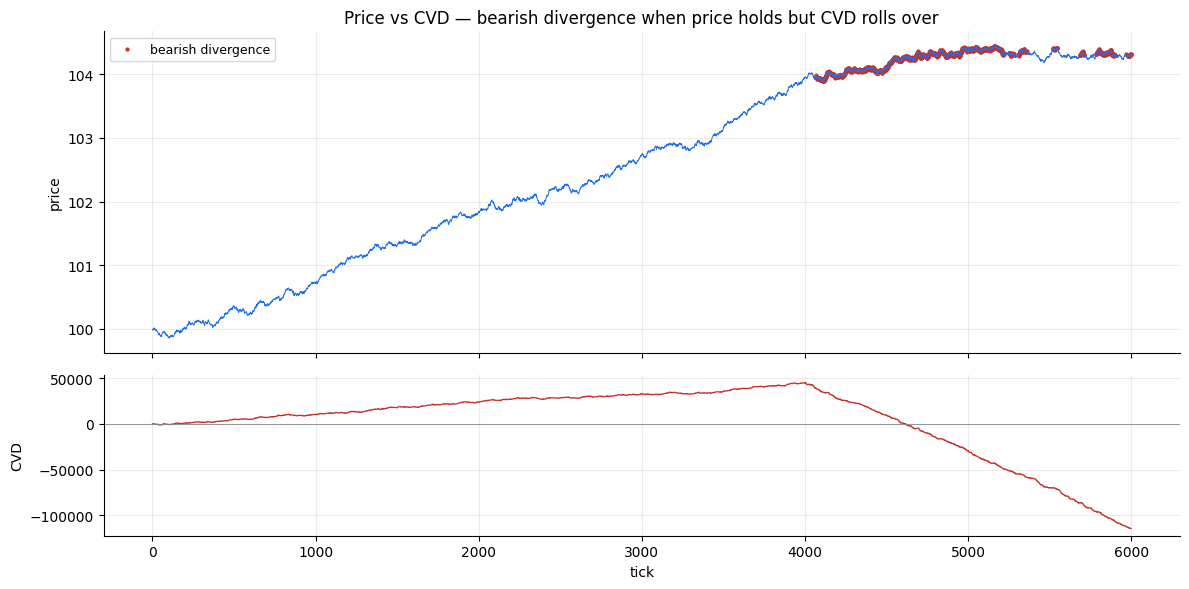

final CVD = -114,363   bearish-divergence ticks flagged = 1409


In [6]:
def make_ticks(n=6000, seed=5):
    rng = np.random.default_rng(seed)
    n1 = n * 2 // 3
    # Phase 1: genuine uptrend on buy-led tape -> CVD rises with price.
    # Phase 2: price only grinds to a marginal higher high...
    drift = np.concatenate([np.full(n1, 0.0007), np.full(n - n1, 0.00015)])
    px = 100.0 + np.cumsum(drift + rng.normal(0, 0.009, n))
    size = rng.gamma(2.0, 50.0, n)
    # ...but in phase 2 the down-ticks carry far more size than the up-ticks, so
    # net aggressor flow turns negative (distribution) even as price holds up.
    down = np.zeros(n, dtype=bool)
    down[1:] = np.diff(px) < 0.0
    heavy = np.ones(n)
    heavy[n1:] = np.where(down[n1:], 2.2, 0.6)
    size = size * heavy
    start = dt.datetime(2024, 3, 4, 14, 30, tzinfo=ZoneInfo('UTC'))
    ts = [start + dt.timedelta(seconds=int(3.9 * i)) for i in range(n)]
    return pl.DataFrame({'timestamp': ts, 'price': px, 'size': size})

ticks = make_ticks()
cvd = cumulative_volume_delta(ticks)
price = ticks['price'].to_numpy()
div = delta_divergence(price, cvd, window=400)

fig, (axp, axc) = plt.subplots(2, 1, sharex=True, height_ratios=[2, 1], figsize=(12, 6))
axp.plot(price, color='#1f6feb', lw=0.7); axp.set_ylabel('price')
bear = np.flatnonzero(div < 0)
if bear.size:
    axp.scatter(bear, price[bear], color='#c4302b', s=4, label='bearish divergence')
    axp.legend(fontsize=9)
axp.set_title('Price vs CVD — bearish divergence when price holds but CVD rolls over')
axc.plot(cvd, color='#c4302b', lw=0.9); axc.axhline(0, color='#888', lw=0.6)
axc.set_ylabel('CVD'); axc.set_xlabel('tick')
plt.tight_layout(); plt.show()
print(f'final CVD = {cvd[-1]:,.0f}   bearish-divergence ticks flagged = {bear.size}')


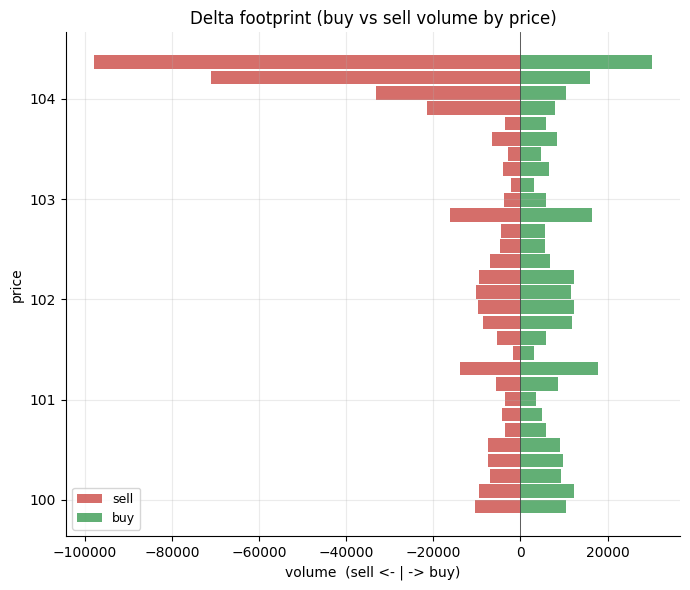

net delta = -114,363  (buys 282,465 vs sells 396,827)


In [7]:
# Delta footprint: buy vs sell volume by price.
dp = delta_profile(ticks, n_bins=30)
c = 0.5 * (dp.price_bins[:-1] + dp.price_bins[1:])
h = (c[1] - c[0]) * 0.9
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(c, -dp.sell_volume, height=h, color='#c4302b', alpha=0.7, label='sell')
ax.barh(c, dp.buy_volume, height=h, color='#1f8e3a', alpha=0.7, label='buy')
ax.axvline(0, color='#444', lw=0.6)
ax.set_title('Delta footprint (buy vs sell volume by price)')
ax.set_xlabel('volume  (sell <- | -> buy)'); ax.set_ylabel('price'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f'net delta = {dp.delta.sum():,.0f}  (buys {dp.buy_volume.sum():,.0f} '
      f'vs sells {dp.sell_volume.sum():,.0f})')


## 5. Profile shape — balance vs trend

The *shape* of the volume distribution classifies the session. A **balance day**
concentrates volume at one price → high Gini, low entropy, a fat **D**-profile. A
**trend day** spreads volume thinly across the range → low Gini, high entropy.
`classify_profile_shape` bundles the Gini coefficient, normalised entropy,
volume-weighted skew/kurtosis, and a coarse shape label.


                Gini  entropy    skew  kurtosis   shape
balance        0.418    0.919   -0.15     -0.43       D
trend          0.293    0.962   -0.02     -1.16  normal

Balance day = concentrated (high Gini, low entropy); trend day = dispersed.


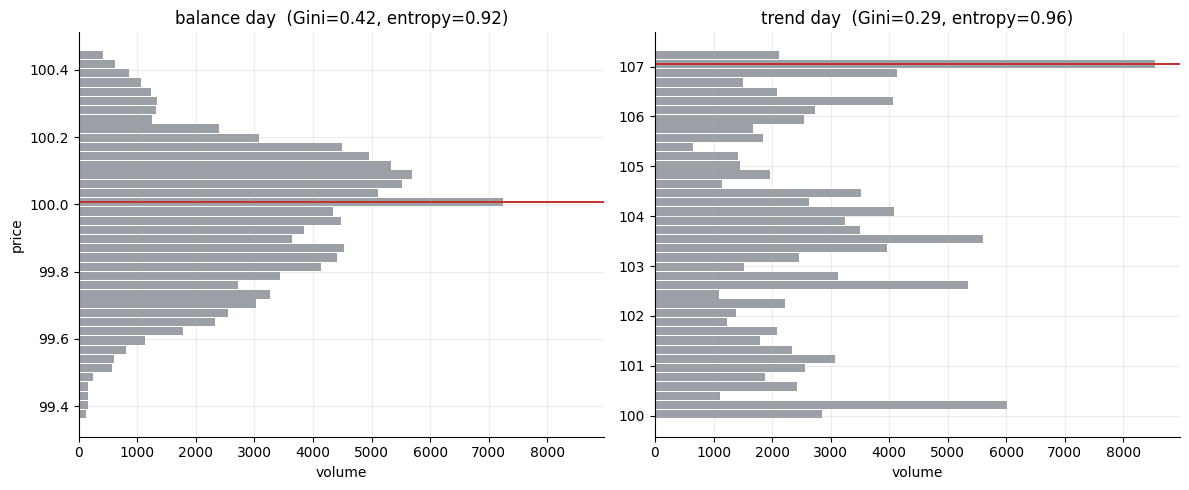

In [8]:
pb = volume_profile(bal, n_bins=40)
pt = volume_profile(trend, n_bins=40)
sb = classify_profile_shape(pb)
st = classify_profile_shape(pt)
print(f'{"":<12}{"Gini":>8}{"entropy":>9}{"skew":>8}{"kurtosis":>10}{"shape":>8}')
for name, s in [('balance', sb), ('trend', st)]:
    print(f'{name:<12}{s.gini:>8.3f}{s.entropy:>9.3f}{s.skew:>8.2f}{s.kurtosis:>10.2f}{s.shape:>8}')
print('\nBalance day = concentrated (high Gini, low entropy); trend day = dispersed.')

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
for ax, prof, title in [(axes[0], pb, 'balance day'), (axes[1], pt, 'trend day')]:
    c = prof.bin_centres
    ax.barh(c, prof.volume, height=(c[1]-c[0]) * 0.9, color='#9aa0a6')
    ax.axhline(prof.poc, color='#c4302b', lw=1.4)
    ax.set_title(f'{title}  (Gini={volume_concentration(prof):.2f}, '
                 f'entropy={volume_entropy(prof):.2f})')
    ax.set_xlabel('volume')
axes[0].set_ylabel('price')
plt.tight_layout(); plt.show()


## What next?

* **Multi-session composites.** `composite_profile` and `value_area_migration`
  build rolling/merged profiles and track how value migrates day to day;
  `naked_pocs` finds untested prior POCs that act as magnets.
* **Anchored VWAP.** `anchored_vwap` from a swing high/low or an event (earnings,
  the open) is a favourite institutional reference — anchor it to a pivot.
* **Lee–Ready signing.** With bid/ask quotes, `signed_tick_volume(method=
  'lee_ready')` classifies aggressors more accurately than the tick rule.
* **Confluence.** Volume nodes, VWAP bands and the gamma-exposure walls (see the
  GEX notebook) often line up — overlapping levels are the highest-conviction
  trade locations.
